In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv(r"C:\Users\Spandan\Downloads\social_media_performance.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:", df.isnull().sum().sum())
print("\nClass distribution:")
print(df["is_viral"].value_counts())

Shape: (10000, 15)

First 5 rows:
   post_id  platform content_type       topic language region  \
0        1  LinkedIn      article  Technology       UR     BR   
1        2  LinkedIn         poll      Health       FR     JP   
2        3  LinkedIn      article      Travel       HI     FR   
3        4  LinkedIn        image      Sports       DE     DE   
4        5  LinkedIn         poll    Business       DE     US   

         post_datetime                                           hashtags  \
0  2025-04-25 09:47:00  #AI #Innovation #TechTrends #Programming #Codi...   
1  2025-10-29 09:44:00  #Fitness #Nutrition #Wellness #Health #MentalH...   
2  2025-02-10 14:12:00  #Travel #Journey #Adventure #Tourism #ExploreM...   
3  2025-04-18 22:41:00                         #Cricket #Workout #Fitness   
4  2025-04-28 10:17:00             #Entrepreneur #Leadership #StartupLife   

   sentiment_score  views  likes  comments  shares  engagement_rate  is_viral  
0             0.76  37781   1202

In [4]:
df["post_datetime"] = pd.to_datetime(df["post_datetime"])
df["hour"]          = df["post_datetime"].dt.hour
df["day_of_week"]   = df["post_datetime"].dt.dayofweek
df["is_weekend"]    = (df["day_of_week"] >= 5).astype(int)

# Hashtag count
df["hashtag_count"] = df["hashtags"].str.count("#")

# Drop raw leaky columns (direct outcomes of virality)
# Keep engagement_rate but add noise to prevent perfect separation
df.drop(columns=["post_id", "post_datetime", "hashtags",
                 "views", "likes", "comments", "shares"], inplace=True)

np.random.seed(42)
noise = np.random.normal(0, df["engagement_rate"].std() * 0.3, size=len(df))
df["engagement_rate"] = df["engagement_rate"] + noise

In [5]:
le = LabelEncoder()
for col in ["platform", "content_type", "topic", "language", "region"]:
    df[col] = le.fit_transform(df[col])

X = df.drop(columns=["is_viral"])
y = df["is_viral"]
print("\nFeatures:", X.columns.tolist())



Features: ['platform', 'content_type', 'topic', 'language', 'region', 'sentiment_score', 'engagement_rate', 'hour', 'day_of_week', 'is_weekend', 'hashtag_count']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("Train size:", X_train.shape, "  Test size:", X_test.shape)

Train size: (8000, 11)   Test size: (2000, 11)


In [8]:
print("\n Bagging Classifier ")
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)
bag.fit(X_train_sc, y_train)
y_pred_bag  = bag.predict(X_test_sc)
y_proba_bag = bag.predict_proba(X_test_sc)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred_bag))


 Bagging Classifier 
Accuracy: 0.884


In [9]:
print("\n Random Forest Classifier ")
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


 Random Forest Classifier 
Accuracy: 0.885


In [10]:
print("\n AdaBoost Classifier ")
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train_sc, y_train)
y_pred_ada  = ada.predict(X_test_sc)
y_proba_ada = ada.predict_proba(X_test_sc)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred_ada))


 AdaBoost Classifier 
Accuracy: 0.8885


In [11]:
print("\n Gradient Boosting Classifier ")
gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb  = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred_gb))



 Gradient Boosting Classifier 
Accuracy: 0.894


In [12]:
print("\n XGBoost Classifier ")
xgb = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=4,
    eval_metric="logloss", random_state=42, verbosity=0
)
xgb.fit(X_train, y_train)
y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))


 XGBoost Classifier 
Accuracy: 0.894


In [13]:
models = {
    "Bagging"           : (y_pred_bag, y_proba_bag),
    "Random Forest"     : (y_pred_rf,  y_proba_rf),
    "AdaBoost"          : (y_pred_ada, y_proba_ada),
    "Gradient Boosting" : (y_pred_gb,  y_proba_gb),
    "XGBoost"           : (y_pred_xgb, y_proba_xgb),
}

for name, (y_pred, _) in models.items():
    sep = "=" * 40
    print(f"\n{sep}\n {name}\n{sep}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred, target_names=["Not Viral", "Viral"]))


 Bagging
Accuracy : 0.8840
              precision    recall  f1-score   support

   Not Viral       0.87      0.88      0.87       909
       Viral       0.90      0.89      0.89      1091

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000


 Random Forest
Accuracy : 0.8850
              precision    recall  f1-score   support

   Not Viral       0.87      0.88      0.87       909
       Viral       0.90      0.89      0.89      1091

    accuracy                           0.89      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.89      0.89      0.89      2000


 AdaBoost
Accuracy : 0.8885
              precision    recall  f1-score   support

   Not Viral       0.88      0.88      0.88       909
       Viral       0.90      0.90      0.90      1091

    accuracy                           0.89      2000
   macro avg       0.89      0.89    

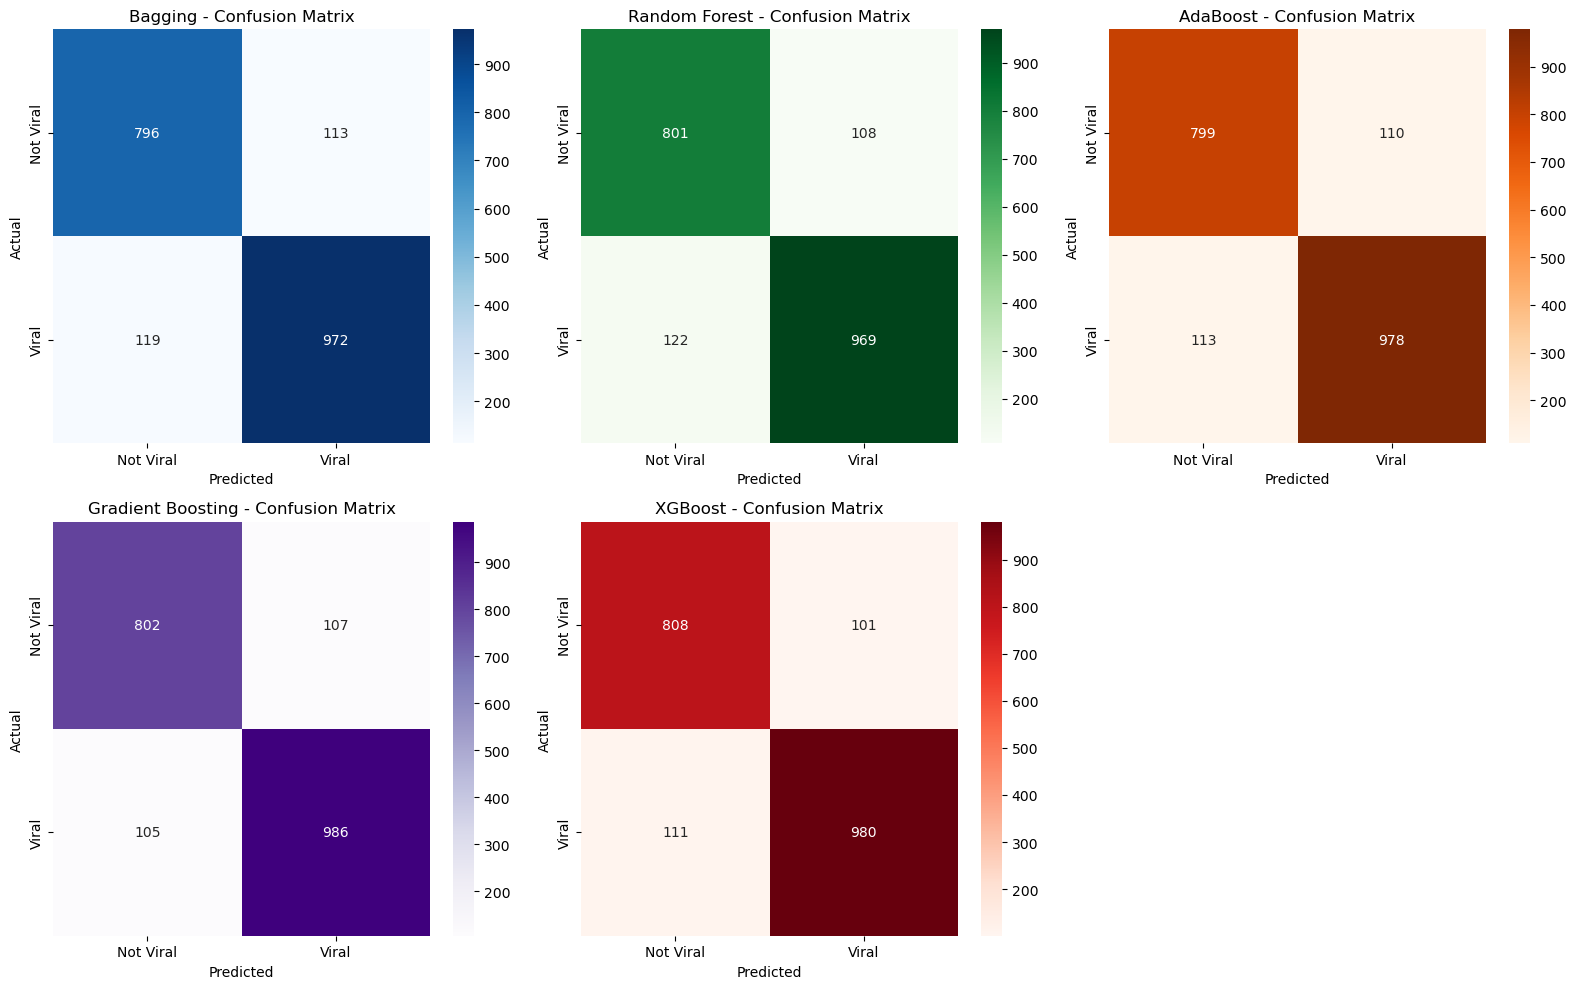

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cmaps = ["Blues", "Greens", "Oranges", "Purples", "Reds"]

for ax, (name, (y_pred, _)), cmap in zip(axes.flat, models.items(), cmaps):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=["Not Viral", "Viral"],
                yticklabels=["Not Viral", "Viral"])
    ax.set_title(f"{name} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

axes[1, 2].set_visible(False)
plt.tight_layout()
plt.show()

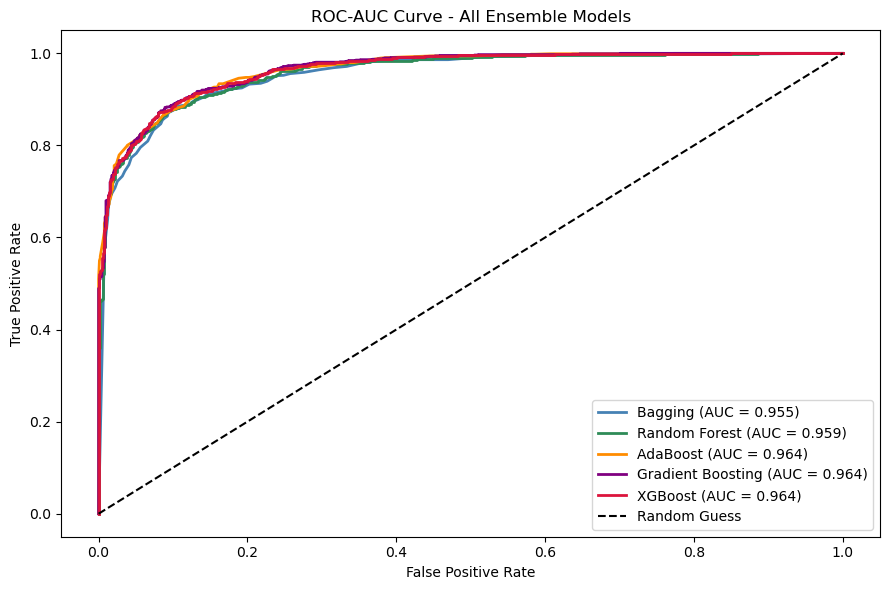

In [15]:
plt.figure(figsize=(9, 6))
colors = ["steelblue", "seagreen", "darkorange", "purple", "crimson"]

for (name, (_, y_proba)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score   = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})", color=color, lw=2)

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve - All Ensemble Models")
plt.legend()
plt.tight_layout()
plt.show()

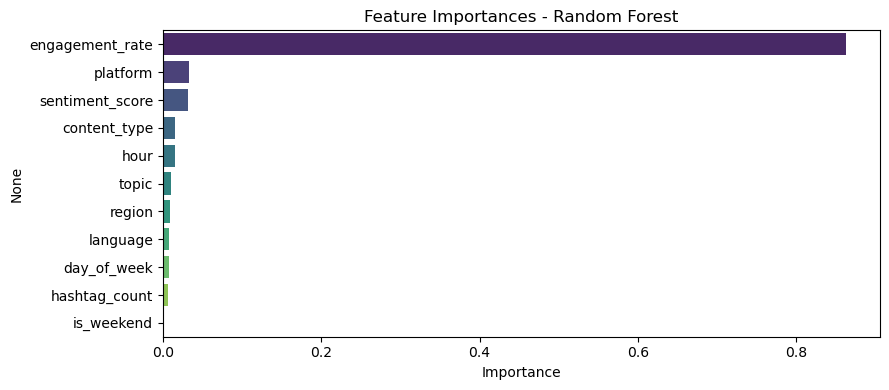

In [16]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(x=feat_imp.values, y=feat_imp.index,
            hue=feat_imp.index, palette="viridis", legend=False)
plt.title("Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [17]:
summary = pd.DataFrame({
    "Model"   : list(models.keys()),
    "Accuracy": [round(accuracy_score(y_test, yp), 4) for yp, _  in models.values()],
    "AUC"     : [round(auc(*roc_curve(y_test, ypr)[:2]), 4) for _, ypr in models.values()],
})
print("\nModel Comparison Summary:")
print(summary.to_string(index=False))


Model Comparison Summary:
            Model  Accuracy    AUC
          Bagging    0.8840 0.9549
    Random Forest    0.8850 0.9590
         AdaBoost    0.8885 0.9641
Gradient Boosting    0.8940 0.9643
          XGBoost    0.8940 0.9640
